# Notebook 03 — Rotation Correction

> **Supplementary §5**

This notebook separates whole-body rotation from intrinsic wing–tail morphing. PCA components that describe bilaterally symmetric motion (wing lifting and spreading) are used to construct a "symmetrical projection" — a version of the data with no banking or yawing. The Kabsch algorithm then finds the optimal rotation matrix between the original and projected data for each frame, which we invert to remove roll, yaw, and residual pitch.

## Contents
1. [Setup and data loading](#setup)
2. [Assessing component symmetry](#assessing-component-symmetry)
3. [Projecting to symmetrical components](#projecting-to-symmetrical-components)
4. [Computing rotation matrices (Kabsch)](#computing-rotation-matrices)
5. [Applying the rotation correction](#applying-the-rotation-correction)
6. [Visualising the correction](#visualising-the-correction)
7. [Euler angle extraction](#euler-angle-extraction)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=3)

from morphing_birds import Animal3D, animate_plotly, animate_compare

from kinematic_morphospace import (
    filter_by, reconstruct,
    assess_symmetry, vectorised_kabsch,
    extract_euler_angles_from_matrices, apply_rotation,
    get_score_df, get_binned_scores,
)
from kinematic_morphospace.plotting import (
    plot_symmetry_scores,
    plot_explained, plot_whole_body_angles,
    plot_angles_by_distance, plot_bird_marker_comparisons,
    save_figure,
)

## Load Data from Previous Notebook

We load the wingspan-normalised bilateral markers (originally in metres, divided by each bird's maximum wingspan ~1.05 m), metadata, and the PCA results computed in Notebook 02.

In [2]:
# Load processed data from Notebook 02
markers_with_tailpack = np.load("../../data/processed/scaled_markers_with_tailpack.npy")
combined_frame_info_df = pd.read_csv("../../data/processed/combined_frame_info_df.csv")

# Load PCA results
pca_results = np.load("../../data/processed/whole_body_pca_results.npy", allow_pickle=True).item()
principal_components = pca_results["principal_components"]
scores = pca_results["scores"]
pca_mean = pca_results["pca_mean"]

print(f"Markers shape: {markers_with_tailpack.shape}")
print(f"Frames: {len(combined_frame_info_df):,}")
print(f"PCA components shape: {principal_components.shape}")
print(f"Scores shape: {scores.shape}")

Markers shape: (144764, 9, 3)
Frames: 144,764
PCA components shape: (27, 27)
Scores shape: (144764, 27)


## Assessing Component Symmetry

To identify which principal components describe bilaterally symmetric motion (and are therefore uncontaminated by whole-body rotation), we compute a symmetry score for each component.

The procedure:
1. Reshape each component from [27] to [9 markers, 3 coordinates].
2. Mirror the left-side markers across the x-axis (sagittal plane).
3. Compute the sum-of-squared differences between the original and mirrored loadings.

A low symmetry score (< 0.01) indicates the component describes a bilaterally symmetric shape change. A high score indicates asymmetry, consistent with whole-body rotation (roll, yaw).

To give the scores a physical interpretation, we also scale each eigenvector by its score standard deviation before measuring asymmetry. This reconstructs the typical (±1 SD) marker displacement that each PC produces, so the resulting left-right difference is directly in the data's units (wingspan fractions, convertible to millimetres).

Saved: ../../figures/supplementary/S05_asymmetry_scores.pdf

PC    Score        RMS asymmetry
————— —————————— ———————————————
PC 1  0.0006              3.8 mm  (symmetric)
PC 2  0.0026              4.9 mm  (symmetric)
PC 3  0.3060             23.0 mm  (asymmetric)
PC 4  1.6708             59.2 mm  (asymmetric)


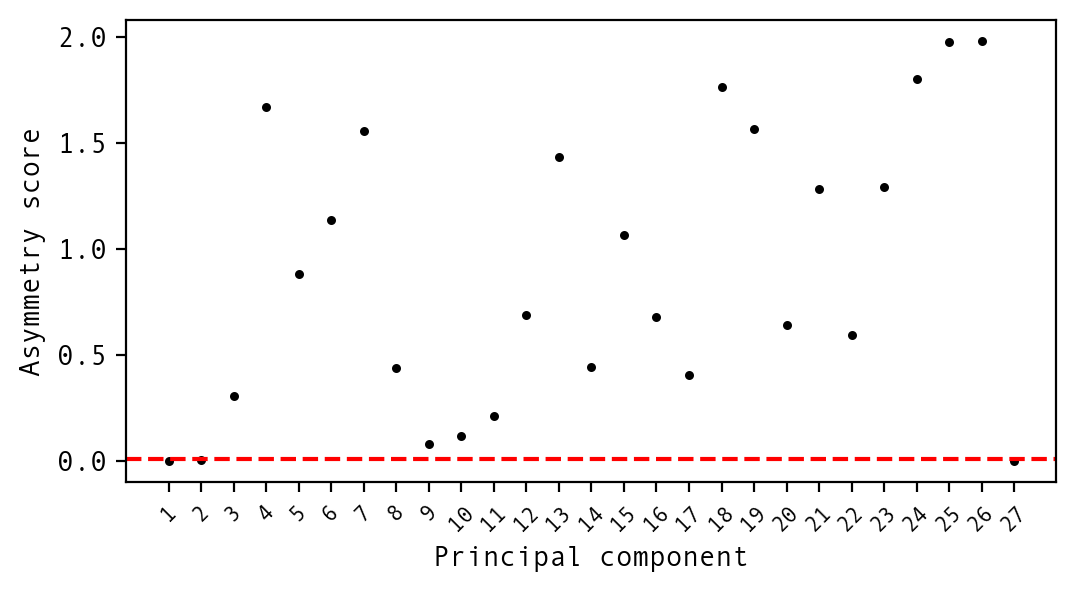

In [3]:
# Reshape components for symmetry assessment
nMarkers = markers_with_tailpack.shape[1]
n_components = principal_components.shape[0]
n_pairs = 4  # 8 bilateral markers in 4 left-right pairs
avg_wingspan_m = 1.05  # approximate mean across birds

score_stds = np.std(scores, axis=0)

symmetry_scores = []
symmetry_rms_mm = []
for i in range(n_components):
    pc = principal_components[i].reshape(nMarkers, 3)
    pc_bilateral = pc[:-1]

    # Raw score (dimensionless) — used for threshold classification
    raw = assess_symmetry(pc_bilateral, 'x', nMarkers=nMarkers - 1)
    symmetry_scores.append(raw)

    # Physical score — scale loadings by score SD so displacement is
    # in wingspan fractions, then measure asymmetry in those units
    displacement = pc_bilateral * score_stds[i]
    physical = assess_symmetry(displacement, 'x', nMarkers=nMarkers - 1)
    rms_mm = np.sqrt(physical / n_pairs) * avg_wingspan_m * 1000
    symmetry_rms_mm.append(rms_mm)

symmetry_scores = np.array(symmetry_scores)
symmetry_rms_mm = np.array(symmetry_rms_mm)

# Plot symmetry scores with threshold
fig, ax = plot_symmetry_scores(symmetry_scores, threshold=0.01)
save_figure(fig, '../../figures/supplementary/S05_asymmetry_scores.pdf')

# Report raw scores and physical RMS asymmetry per marker pair (±1 SD frame)
print(f"\n{'PC':<5} {'Score':<10} {'RMS asymmetry':>15}")
print(f"{'—'*5} {'—'*10} {'—'*15}")
for i in range(4):
    label = "symmetric" if symmetry_scores[i] < 0.01 else "asymmetric"
    print(f"PC {i+1:<2} {symmetry_scores[i]:<10.4f} {symmetry_rms_mm[i]:>12.1f} mm  ({label})")

### Symmetry Score Interpretation

The raw symmetry score (sum of squared loading differences) is dimensionless — the eigenvectors are unit-norm — and is used for threshold classification. The physical RMS asymmetry column shows how much left and right markers would differ (per pair, in millimetres) for a typical frame at ±1 standard deviation of scores along that PC.

**PC 1** (wing lifting) and **PC 2** (wing spreading) have raw scores well below the 0.01 threshold. Their physical left-right asymmetries are a few millimetres — within the noise floor of the motion-capture system.

**PCs 3+** have raw scores orders of magnitude above the threshold, with physical asymmetries of several centimetres — consistent with whole-body rotation (roll, yaw) rather than morphing.

The first two symmetric components explain **> 83%** of total variance and contain no detectable whole-body rotation. We use these two components to construct a rotation-free reference shape for each frame, and then apply the **Kabsch algorithm** (a least-squares method for finding the optimal rigid rotation between two paired point sets) to compute and remove the whole-body rotation from the original data.

## Projecting to Symmetrical Components

We reconstruct the marker data using only the two symmetric components (PC 1 and PC 2). This "symmetrical projection" removes all rotation-related variation while preserving the dominant wing lifting and spreading motions.

$$\hat{X} = S_{[0,1]} \cdot P_{[0,1]}^T + \mu$$

This projection is used only as a preprocessing step for rotation correction — it is **not** used for the final morphing analysis.

In [4]:
# Project data onto the two symmetric components only
symmetric_components = [0, 1]
mean_shape = pca_mean.reshape(1, -1, 3)

symmetric_projection = reconstruct(
    scores, principal_components, mean_shape,
    components_list=symmetric_components,
)
print(f"Symmetric projection shape: {symmetric_projection.shape}")

Symmetric projection shape: (144764, 9, 3)


## Computing Rotation Matrices

The Kabsch algorithm finds the optimal rigid rotation matrix (minimising RMSD) that aligns each original frame to its symmetrical projection. This rotation captures the roll, yaw, and residual pitch for every frame.

The algorithm performs a partial Procrustes alignment (rotation only — no translation or scaling, as the data is already centred and wingspan-normalised).

In [5]:
# Compute per-frame rotation matrices using the Kabsch algorithm
rotation_matrices = vectorised_kabsch(markers_with_tailpack, symmetric_projection)
print(f"Rotation matrices shape: {rotation_matrices.shape}")  # (N, 3, 3)

Rotation matrices shape: (144764, 3, 3)


## Applying the Rotation Correction

We apply the inverse rotation to each frame, removing the whole-body rotation component. The resulting "transformed markers" contain only intrinsic wing and tail morphing.

In [6]:
# Apply rotation to remove whole-body rotation
transformed_markers = apply_rotation(markers_with_tailpack, rotation_matrices)
print(f"Transformed markers shape: {transformed_markers.shape}")

# Save for subsequent notebooks
np.save("../../data/processed/transformed_markers_with_tailpack.npy", transformed_markers)

Transformed markers shape: (144764, 9, 3)


## Visualising the Correction

### Marker distributions before and after

The transformed markers should be much more tightly aligned than the originals. Before correction, markers are "smeared" by banking and turning. After correction, marker trajectories more closely reflect true muscle-driven movement.

Note: both plots contain the same number of data points. The rotation is rigid — distances between markers within each frame are unchanged.

Before rotation correction:


Toothless Number of points: 453480, Number of sequences: 477
Drogon Number of points: 235448, Number of sequences: 466
Ruby Number of points: 170816, Number of sequences: 243
Rhaegal Number of points: 223200, Number of sequences: 327


Charmander Number of points: 75168, Number of sequences: 121


Saved: ../../figures/supplementary/S03_unlabelled_markers.pdf

After rotation correction:
Toothless Number of points: 453480, Number of sequences: 477
Drogon Number of points: 235448, Number of sequences: 466
Ruby Number of points: 170816, Number of sequences: 243
Rhaegal Number of points: 223200, Number of sequences: 327


Charmander Number of points: 75168, Number of sequences: 121


Saved: ../../figures/supplementary/S05_corrected_markers.pdf


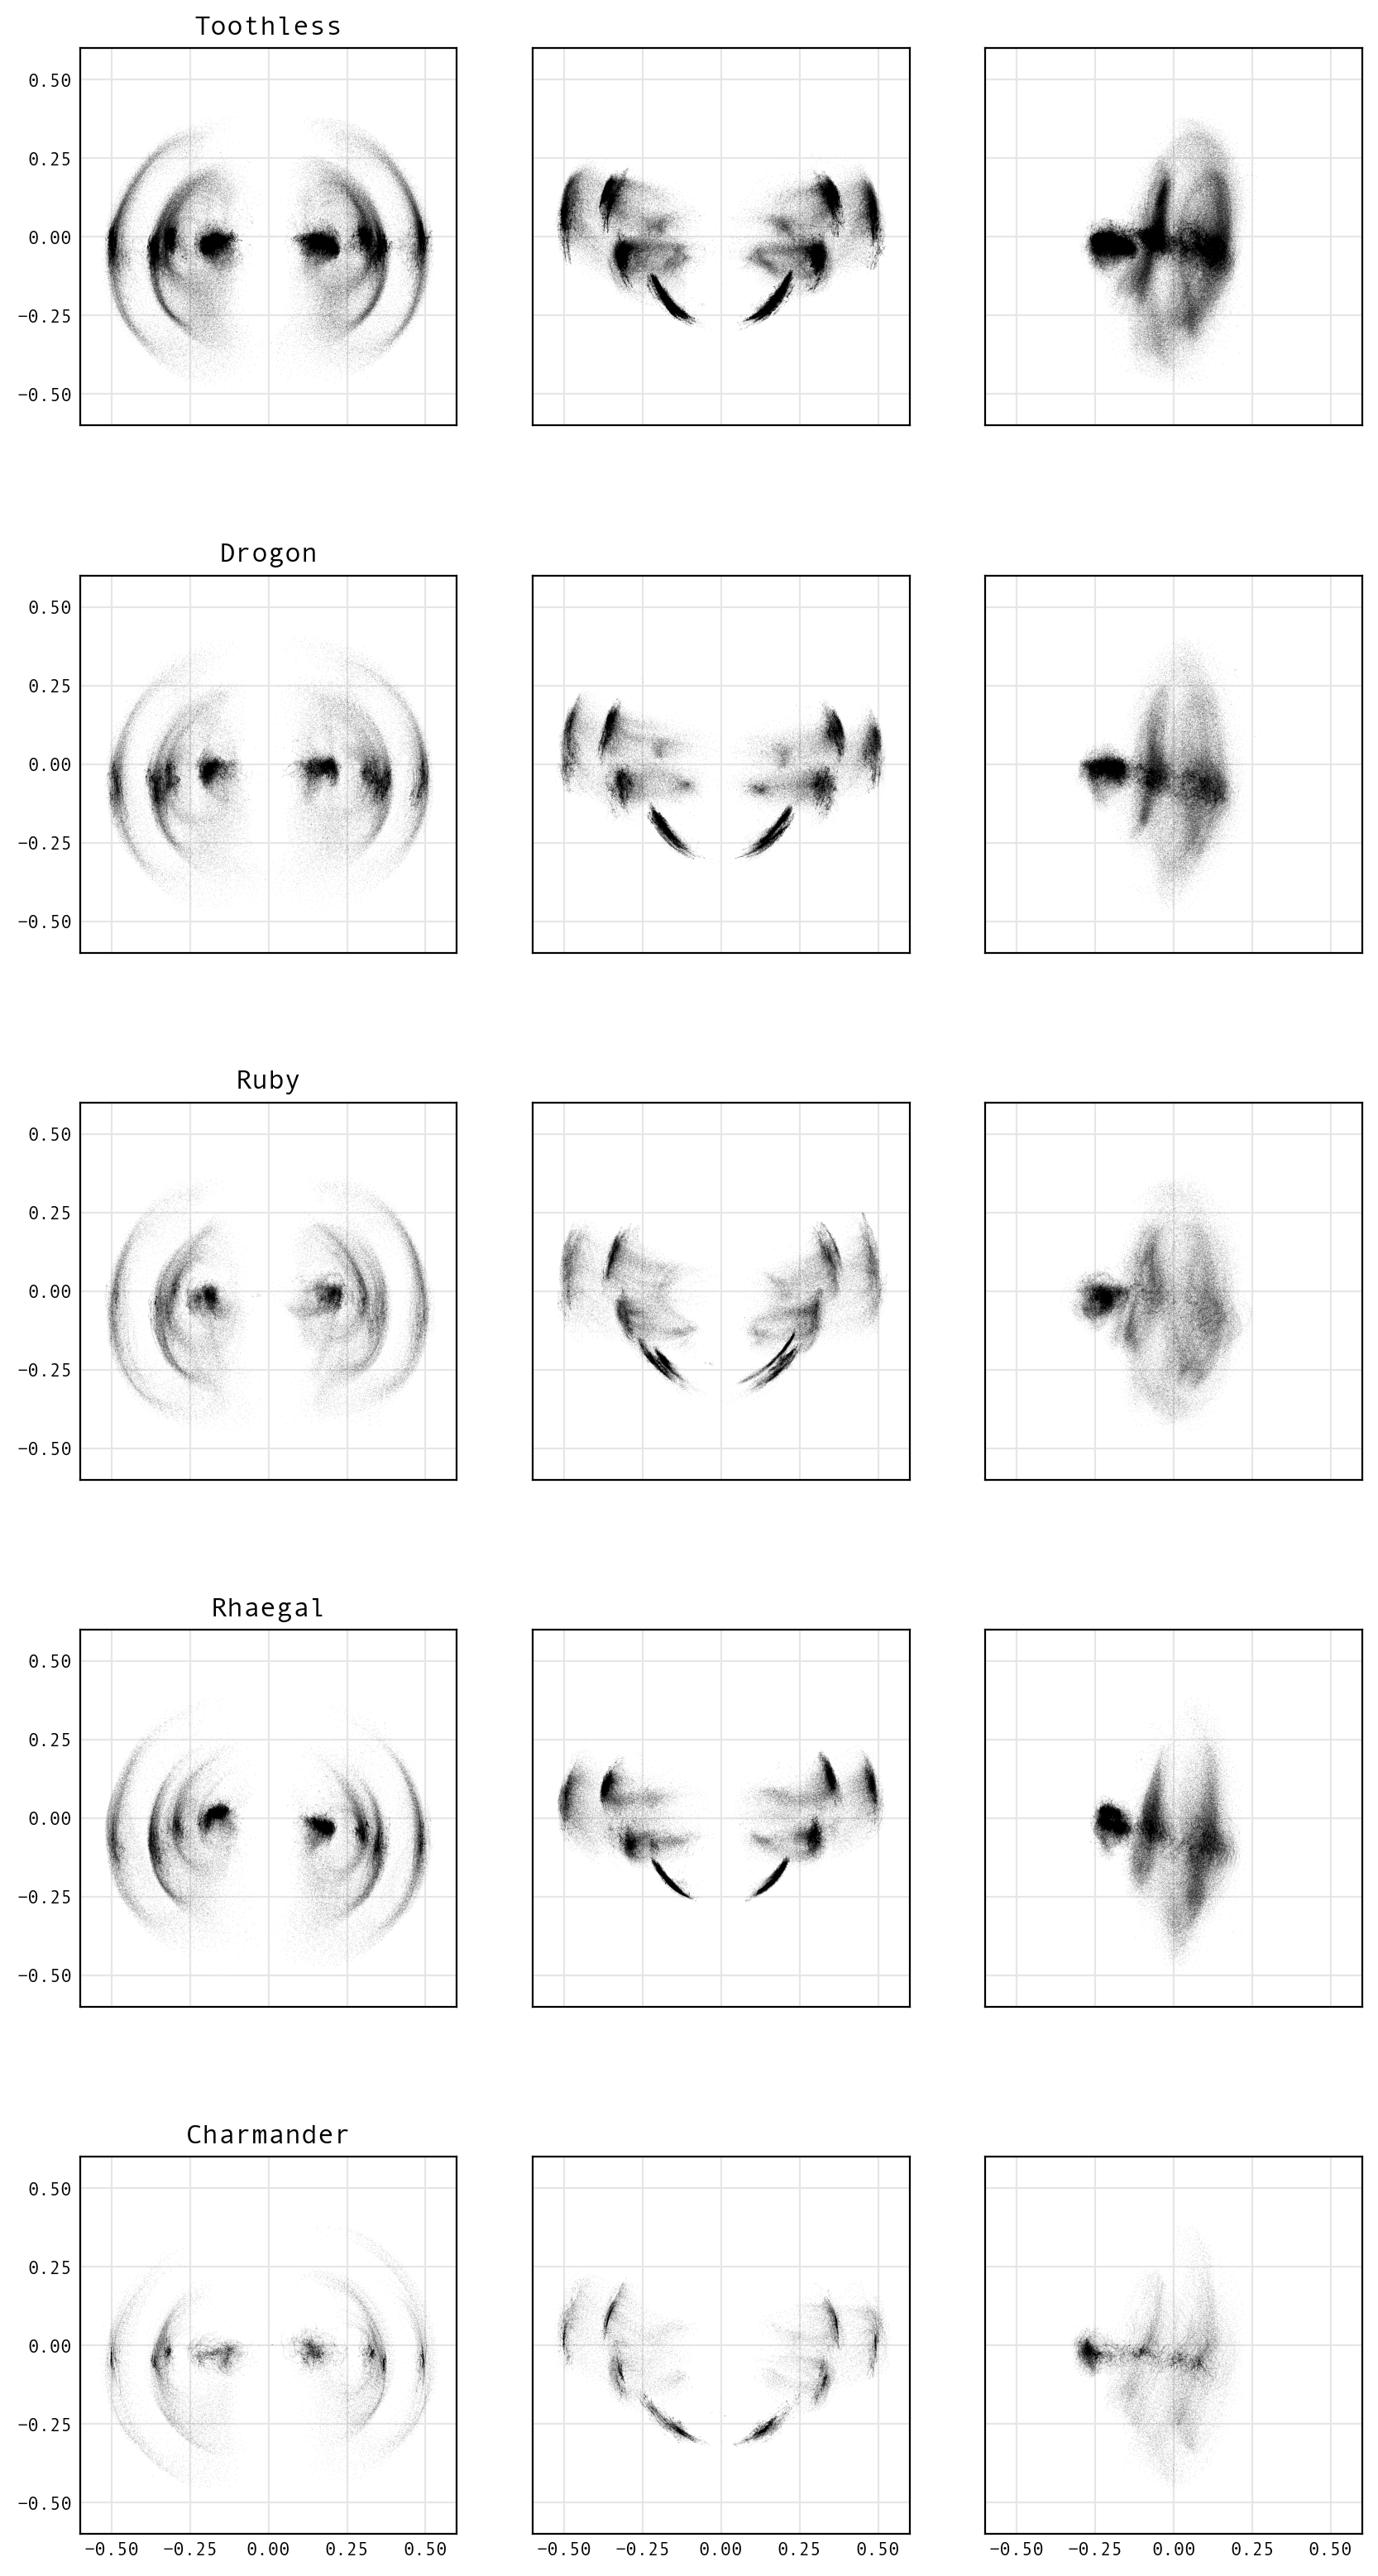

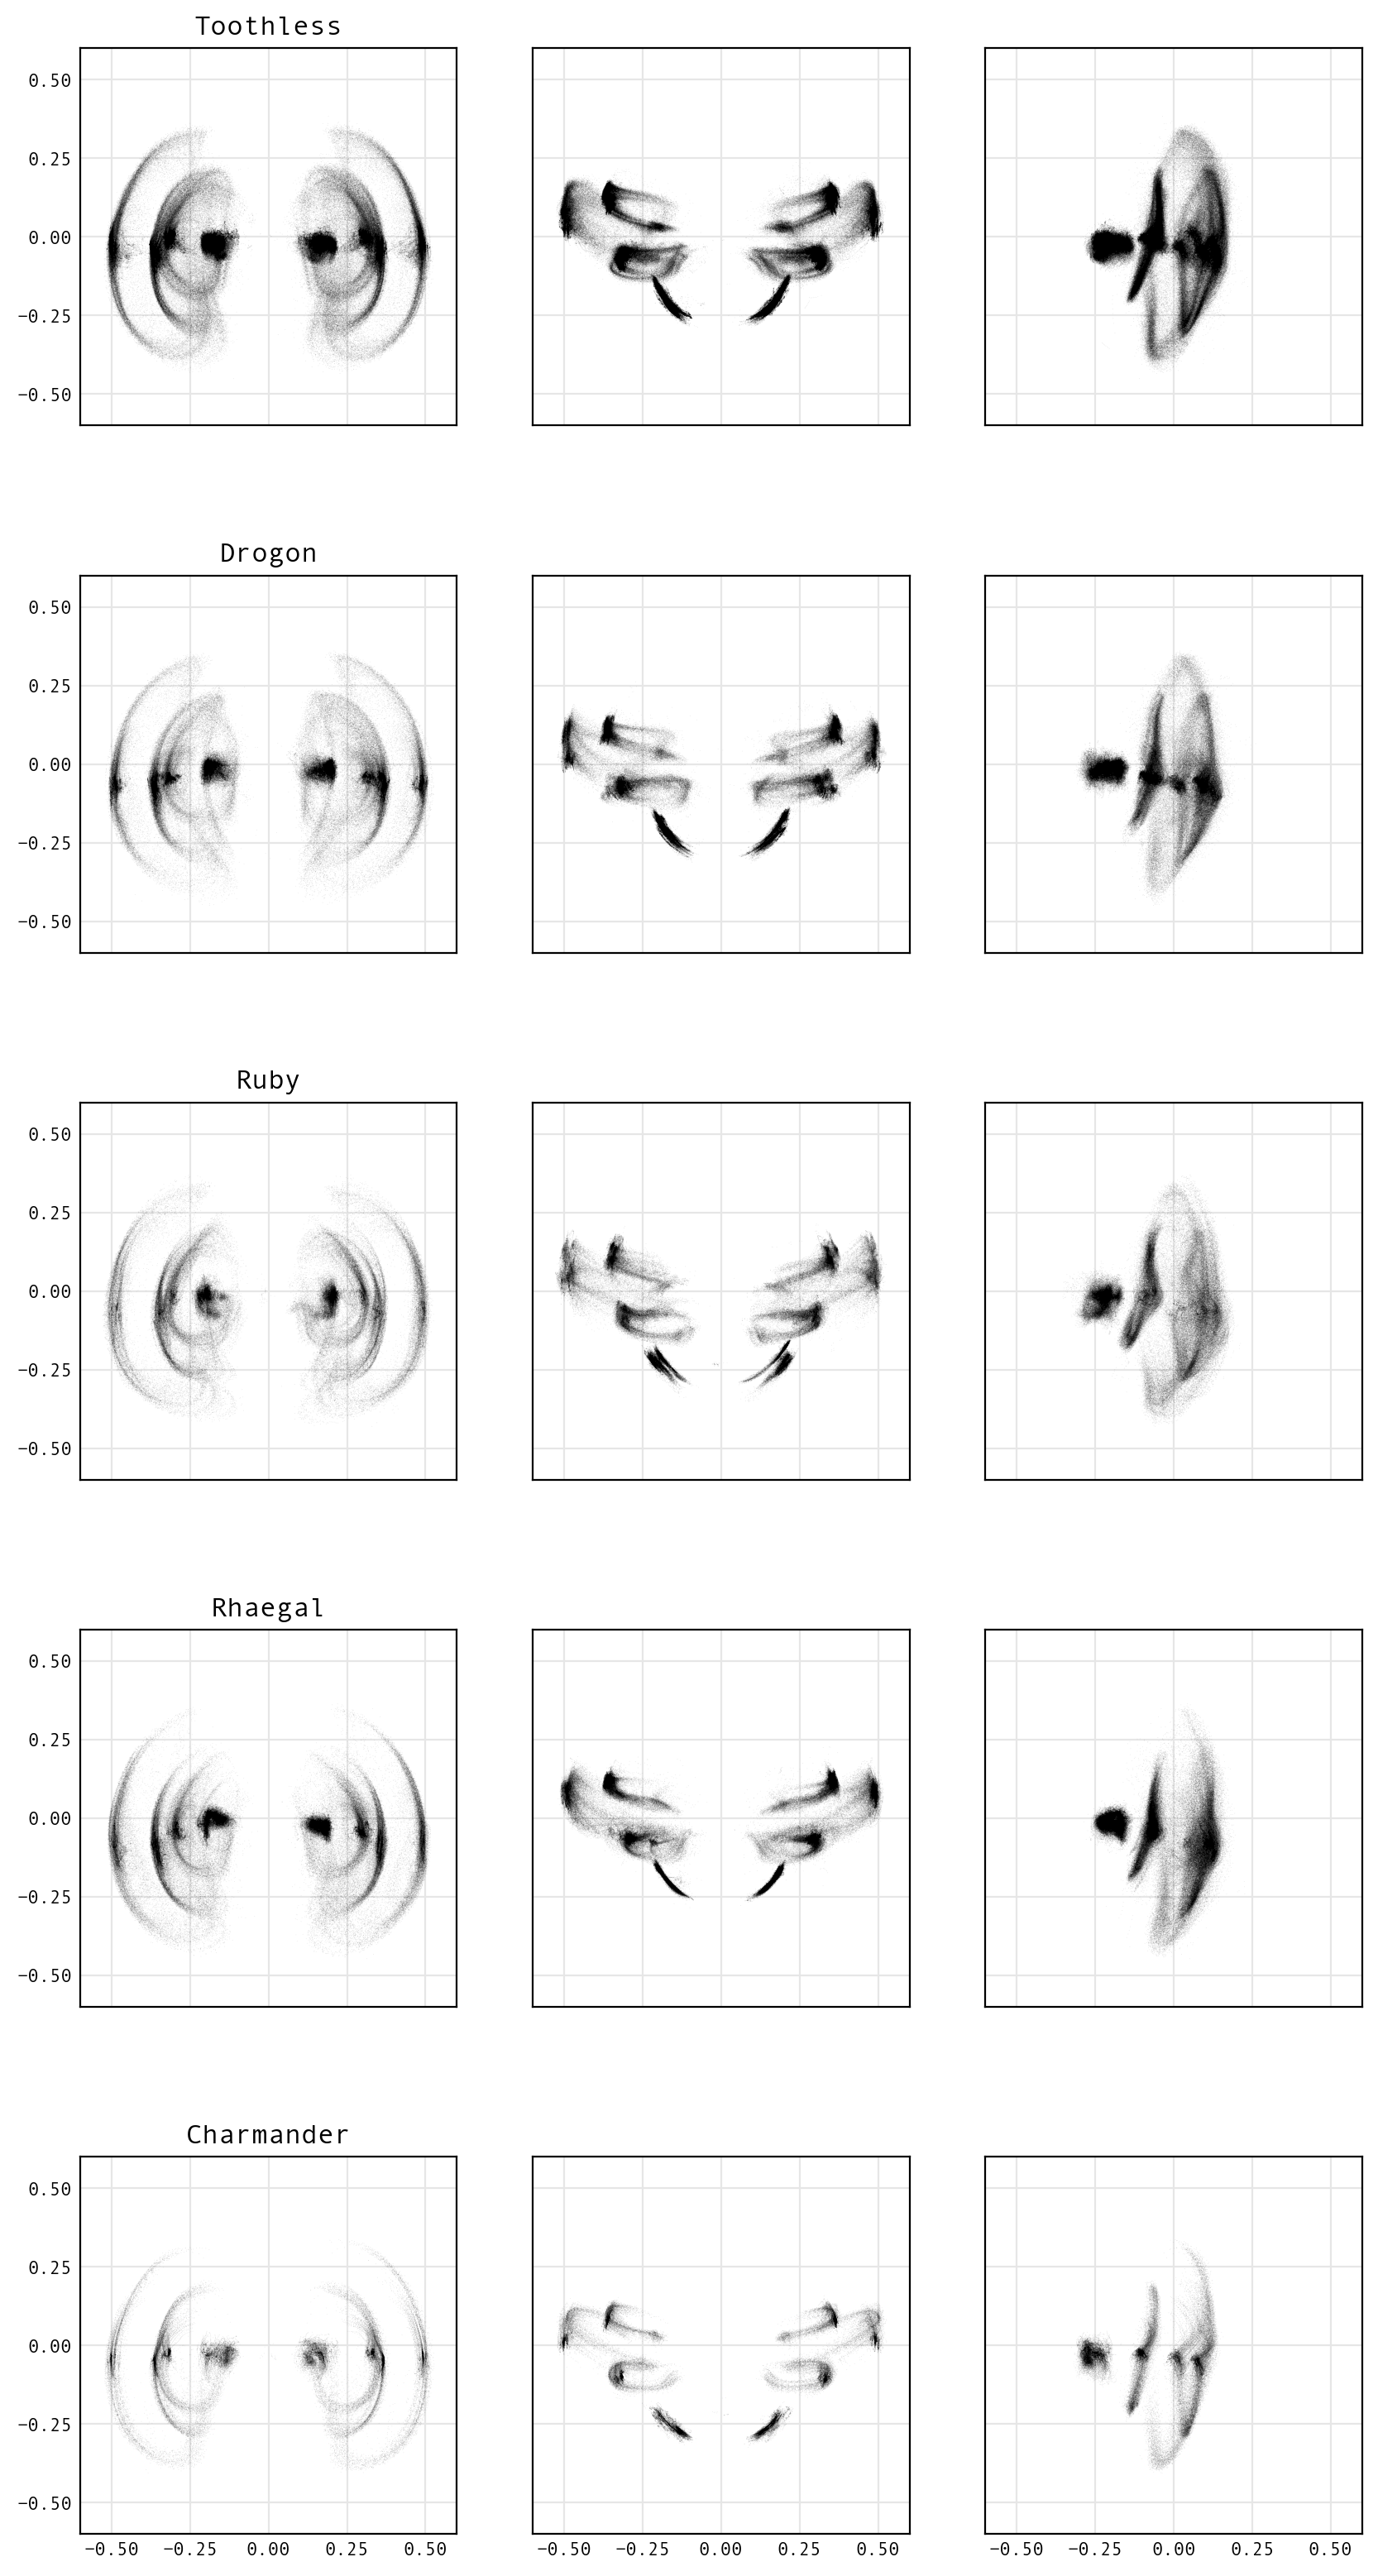

In [7]:
# Plot marker comparisons before and after correction
birds_config = [
    {"bird_id": 4, "name": "Toothless"},
    {"bird_id": 1, "name": "Drogon"},
    {"bird_id": 3, "name": "Ruby"},
    {"bird_id": 2, "name": "Rhaegal"},
    {"bird_id": 5, "name": "Charmander"},
]

print("Before rotation correction:")
fig, axs = plot_bird_marker_comparisons(combined_frame_info_df, markers_with_tailpack, birds_config)
save_figure(fig, '../../figures/supplementary/S03_unlabelled_markers.pdf', rasterize=True)

print("\nAfter rotation correction:")
fig, axs = plot_bird_marker_comparisons(combined_frame_info_df, transformed_markers, birds_config)
save_figure(fig, '../../figures/supplementary/S05_corrected_markers.pdf', rasterize=True)

## Euler Angle Extraction

We decompose the rotation matrices into Euler angles (roll, yaw, pitch) using the X-Z-Y rotation sequence. These angles describe how much the hawk's body rotated in each frame and are useful for visualising banking behaviour during turns.

The estimated body pitch from the backpack–tailpack vector is also available in the frame metadata.

Saved: ../../figures/supplementary/S05_angles_obstacle.pdf


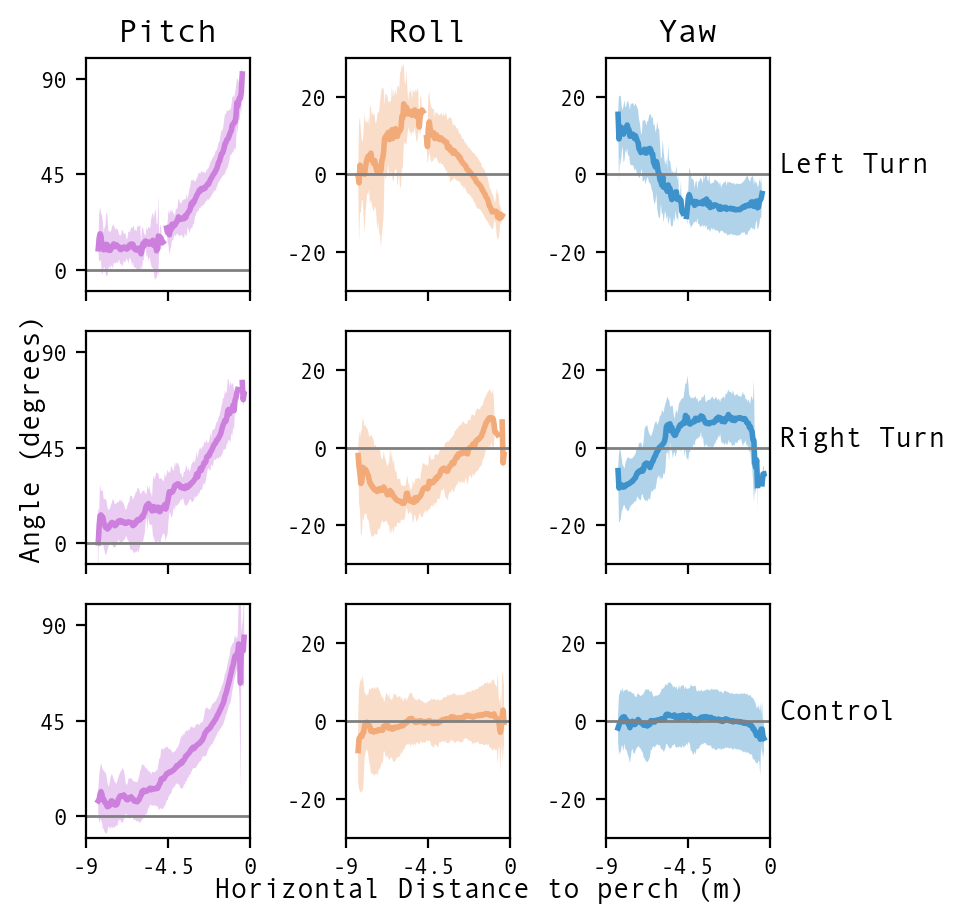

In [8]:
# Extract Euler angles from the rotation matrices
euler_angles = extract_euler_angles_from_matrices(rotation_matrices, sequence='xzy')

# Plot whole-body rotation angles
fig, ax = plot_whole_body_angles(combined_frame_info_df, euler_angles)
save_figure(fig, '../../figures/supplementary/S05_angles_obstacle.pdf')

# Save angles for later analysis
combined_frame_info_df["body_roll"] = euler_angles[:, 0]
combined_frame_info_df["body_yaw"] = euler_angles[:, 1]
combined_frame_info_df.to_csv("../../data/processed/withangles_frame_info_df.csv", index=False)

Saved: ../../figures/supplementary/S05_angles_by_distance.pdf


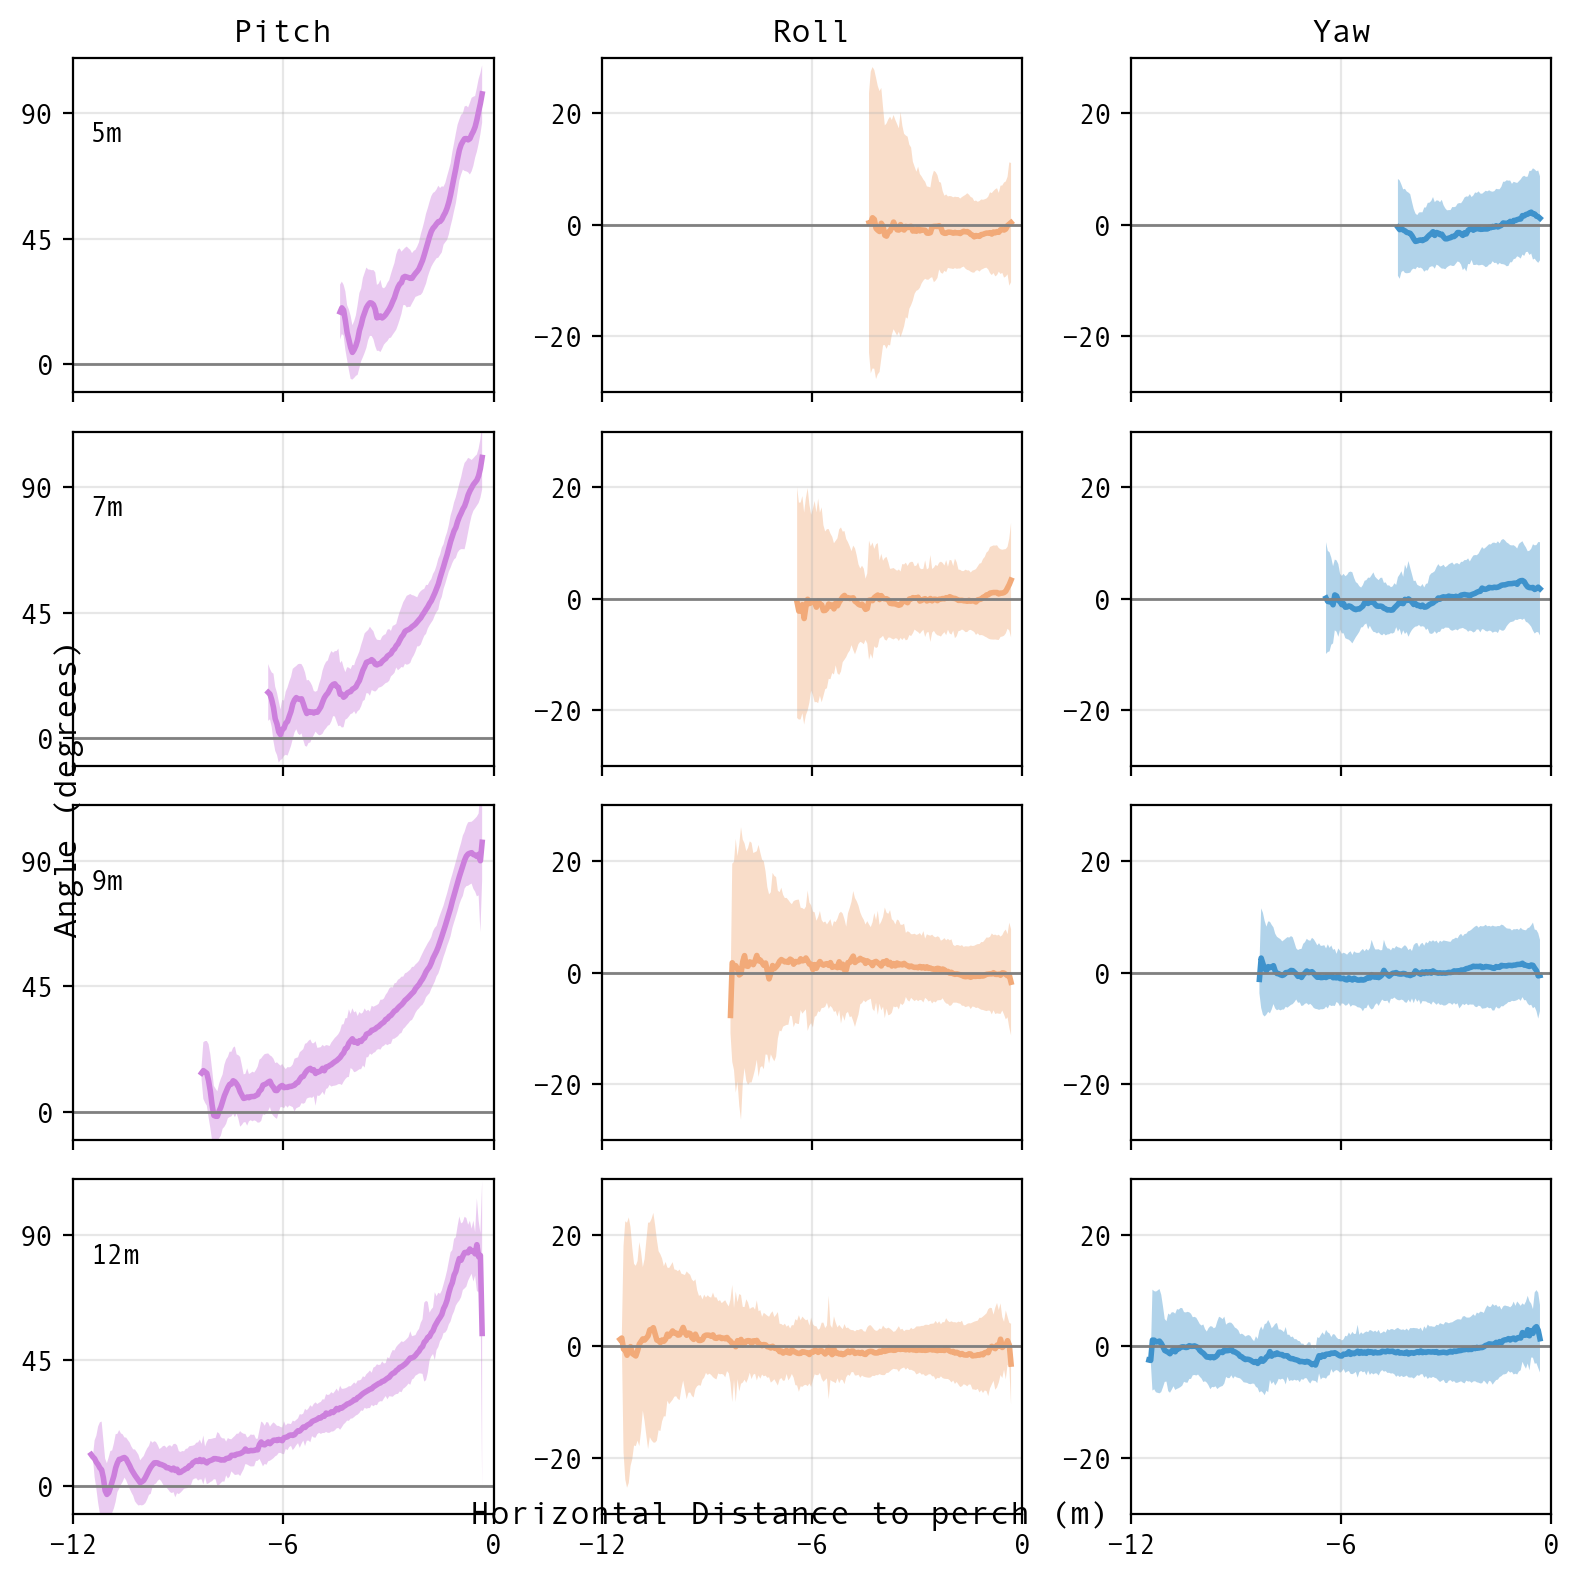

In [9]:
# Plot angles as a function of distance to perch
fig, ax = plot_angles_by_distance(combined_frame_info_df, euler_angles)
save_figure(fig, '../../figures/supplementary/S05_angles_by_distance.pdf')

## Summary

The rotation correction procedure:
1. **Identified** that only PC 1 (wing lifting) and PC 2 (wing spreading) are bilaterally symmetric — their physical left-right asymmetry is only a few millimetres, versus centimetres for the rotation-dominated components.
2. **Projected** the data onto these two components to create a rotation-free reference.
3. **Computed** per-frame rotation matrices via the Kabsch algorithm.
4. **Applied** the inverse rotation to remove roll, yaw, and residual pitch.

The transformed dataset now contains only intrinsic wing and tail morphing, ready for the unilateral PCA in Notebook 04.

### Limitations
- The method assumes that wing lifting and spreading are truly symmetric; any genuine asymmetry in these motions is attributed to body rotation.
- During extreme morphing (e.g., peak upstroke), the PCA-based rotation estimate may introduce small systematic errors. This trade-off is deemed acceptable.
- Roll cannot be distinguished from coordinated anti-symmetrical wing control, but symmetric control is the more parsimonious interpretation (Ros *et al.* 2011).

---

## References

- Kabsch, W. (1976). A solution for the best rotation to relate two sets of vectors. *Acta Crystallographica Section A*, 32, 922–923.
- Gower, J. C. (1975). Generalized Procrustes analysis. *Psychometrika*, 40, 33–51.
- Rohlf, F. J. & Slice, D. (1990). Extensions of the Procrustes method for the optimal superimposition of landmarks. *Systematic Zoology*, 39, 40–59.
- Ros, I. G., Bassman, L. C., Badger, M. A., Pierson, A. N. & Biewener, A. A. (2011). Pigeons steer like helicopters and generate down- and upstroke lift during low speed turns. *Proceedings of the National Academy of Sciences*, 108, 19990–19995.